In [49]:
# Magic Command 
# Print multiple statements in same line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
print("Magic Command Executed")

Magic Command Executed


# Project : Build a Neural Network to Classify Handwritten Digits 

**Goal of This Project**

We will build a neural network that can recognize handwritten digits (0–9) using 
the famous MNIST dataset



**What is the MNIST Dataset?**

***The MNIST dataset is a collection of 70,000 grayscale images of handwritten digits 
from 0 to 9:***

Each image is 28x28 pixels (i.e., 784 features). 

**Example: 28 × 28 Image**

If an image is 28 pixels wide and 28 pixels high, then:

***28×28=784***

**So the image contains 784 pixels**

It’s a classic dataset used to test and learn image classification techniques. 

Each pixel has a value representing its brightness (for a grayscale image):

0 = Black

255 = White

Values in between = Shades of gray

**The computer treats the value of each pixel as a feature.**

Visual Example

**Suppose we have a tiny 3×3 image:**

10   50   80
20  100  150
30  200  255

The computer converts it into:

[10, 50, 80, 20, 100, 150, 30, 200, 255]

Here:

Feature 1 = 10

Feature 2 = 50

Feature 3 = 80

...

Feature 9 = 255

**So there are 9 features for a 3×3 image.**

**For MNIST Digits Dataset**

A handwritten digit image:

28 × 28 pixels

is converted into: [feature1, feature2, feature3, ..., feature784]

**where each feature is the brightness value of one pixel.**

**Why are features important?**

Machine Learning models cannot directly understand images. They need numbers.

So:

Image

  ↓

Pixels

  ↓

Features (numbers)

  ↓

Machine Learning Model

  ↓

Prediction (0,1,2,...,9)

**Feature:**

A feature is an individual measurable property or characteristic of data that is used by a machine learning model for learning and prediction.

Example: In a 28×28 grayscale image, each pixel value is treated as a feature. Therefore, the image has 784 features.

**Feature = Information used by the model to make a decision.**

**For an image: Pixel values → Features**

**28×28 image → 784 features**

**32×32 RGB image → 32×32×3 = 3072 features (because of Red, Green, and Blue channels)**

# What We'll Learn: 

1. How to load and preprocess image data. 

2. How to build a multi-layer neural network. 

3. How to train, evaluate, and test the model. 

4. How to predict custom digits using Python. 

# Step 1: Import Required Libraries 

In [50]:
import tensorflow as tf 
from tensorflow import keras 
import matplotlib.pyplot as plt 

# Step 2: Load the MNIST Dataset 

Keras gives us MNIST built-in — no download required. 

In [51]:
# Load the dataset 
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data() 

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)



(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


# Step 3: Visualize the Data 

Let's see the first image: 

Text(0.5, 1.0, 'Label: 5')

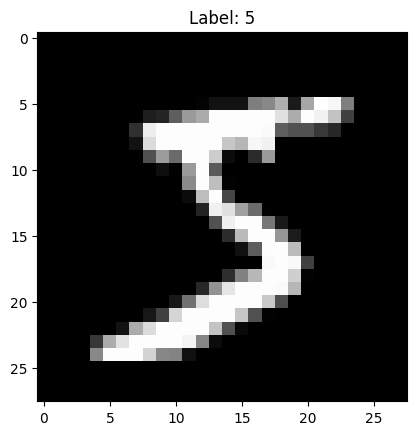

Text(0.5, 1.0, 'Label: 0')

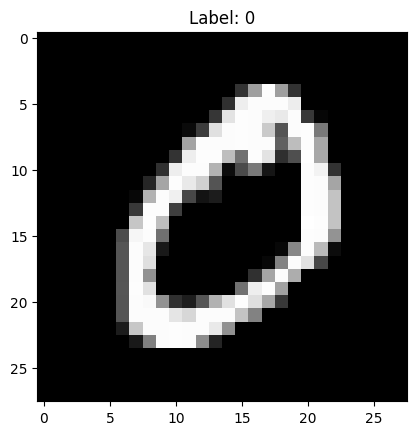

In [52]:
plt.imshow(x_train[0], cmap='gray') 
plt.title(f"Label: {y_train[0]}") 
plt.show()

plt.imshow(x_train[1], cmap='gray') 
plt.title(f"Label: {y_train[1]}") 
plt.show()

# Step 4: Normalize the Data 

Always normalize image pixel values to make the model learn better. 

In [53]:
x_train = x_train / 255.0 
x_test = x_test / 255.0 

# Step 5: Build the Neural Network Model 

**We will use:**

1. An input layer that flattens 28x28 pixels into 784. 

2. Two hidden layers with ReLU. 

3. An output layer with 10 neurons (for 0–9) using Softmax.

In [54]:
model = keras.Sequential([ 
keras.layers.Flatten(input_shape=(28, 28)), 
keras.layers.Dense(128, activation='relu'), 
keras.layers.Dense(64, activation='relu'), 
keras.layers.Dense(10, activation='softmax')  # 10 output classes 
]) 

C:\Users\santo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Step 6: Compile the Model

In [55]:
model.compile(optimizer='adam', 
loss='sparse_categorical_crossentropy', 
metrics=['accuracy'])

# Step 7: Train the Model 

In [56]:
model.fit(x_train, y_train, epochs=5) 
# Tip: You can increase epochs to improve accuracy if needed. 

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8766 - loss: 0.4260
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9690 - loss: 0.1033
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9799 - loss: 0.0659
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9840 - loss: 0.0511
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9884 - loss: 0.0375


# Step 8: Evaluate the Model on Test Data 

In [57]:
test_loss, test_accuracy = model.evaluate(x_test, y_test) 
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9779 - loss: 0.0789
Test accuracy: 0.9812999963760376


# Step 9: Make Predictions 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Predicted 1: 7


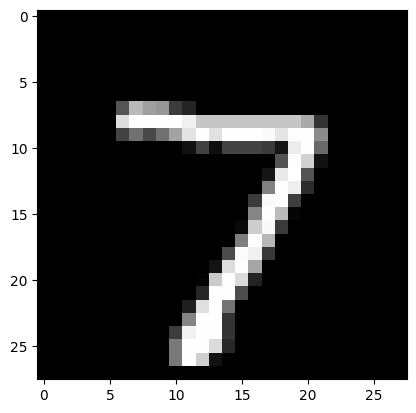

Predicted 2:  2


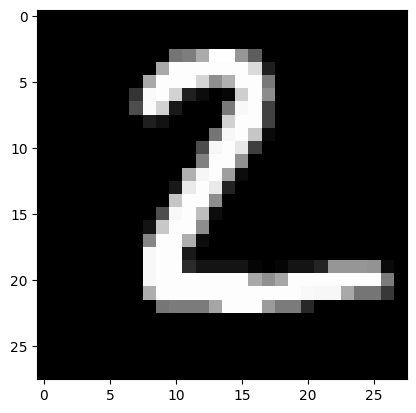

In [58]:
predictions = model.predict(x_test) 
# Predict the first test image 
import numpy as np 
predicted_label = np.argmax(predictions[0]) 
print(f"Predicted 1: {predicted_label}") 
plt.imshow(x_test[0], cmap='gray') 
plt.show()

predicted_label = np.argmax(predictions[1]) 
print(f"Predicted 2:  {predicted_label}") 
plt.imshow(x_test[1], cmap='gray') 
plt.show()

# Step 10: Predict Your Own Digit (Bonus) 

You can draw a digit using any drawing app, resize it to 28x28 pixels, and use it like 
this: 

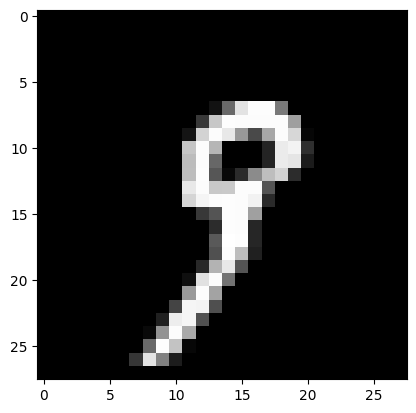

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Digit: 9


In [60]:
from PIL import Image 
import numpy as np 
 
# Load your own digit image (must be 28x28 and grayscale) 
image = Image.open('mnist_test_images\\digit_19_label_9.png').convert('L') 
image = image.resize((28, 28)) 

plt.imshow(image, cmap='gray') 
plt.show()

image_array = np.array(image) / 255.0 
 
# Reshape for model input 
image_array = image_array.reshape(1, 28, 28) 
 
# Predict 
prediction = model.predict(image_array) 
print("Predicted Digit:", np.argmax(prediction)) 

**Summary :**

1. You just built your first AI project using real-world data! 

2. You used TensorFlow + Keras to create a neural network. 

3. You trained it to recognize digits with high accuracy. 

4. You learned how to visualize predictions and test custom images.

# Save MNIST Images as PNG Files Using Python

**Load MNIST and save images to a folder:**

In [ ]:
from tensorflow.keras.datasets import mnist
from PIL import Image
import os

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

folder_path = "mnist_test_images"
# Create output folder
os.makedirs(folder_path, exist_ok=True)

# Save first 20 images
for i in range(20):
    img = Image.fromarray(X_train[i])
    label = y_train[i]

    img.save(f"{folder_path}/digit_{i}_label_{label}.png")

print("Images saved successfully!")

Images saved successfully!


# Read All PNG Files from mnist_test_images (test data)

Total Images Found: 20


Text(0.5, 1.0, 'digit_0_label_5.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

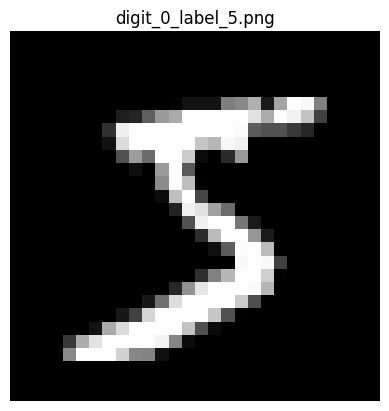

File: digit_0_label_5.png
Predicted Digit: 5
--------------------------------------------------


Text(0.5, 1.0, 'digit_10_label_3.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

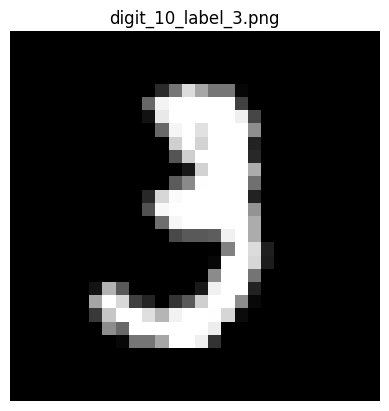

File: digit_10_label_3.png
Predicted Digit: 3
--------------------------------------------------


Text(0.5, 1.0, 'digit_11_label_5.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

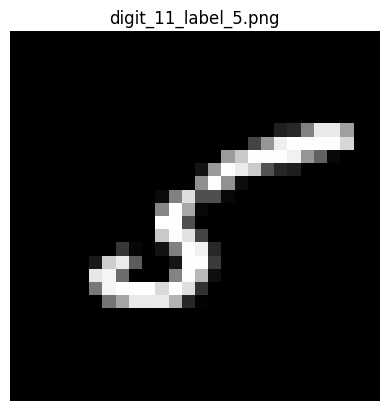

File: digit_11_label_5.png
Predicted Digit: 5
--------------------------------------------------


Text(0.5, 1.0, 'digit_12_label_3.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

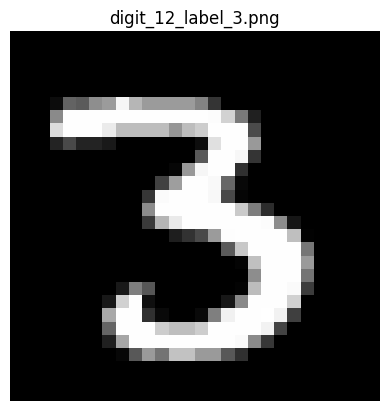

File: digit_12_label_3.png
Predicted Digit: 3
--------------------------------------------------


Text(0.5, 1.0, 'digit_13_label_6.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

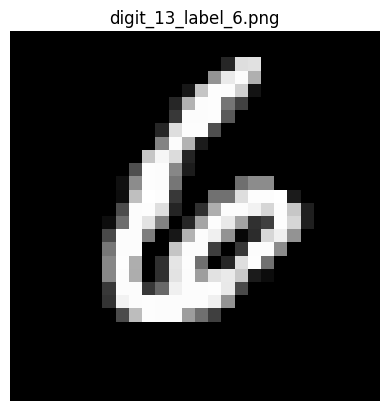

File: digit_13_label_6.png
Predicted Digit: 6
--------------------------------------------------


Text(0.5, 1.0, 'digit_14_label_1.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

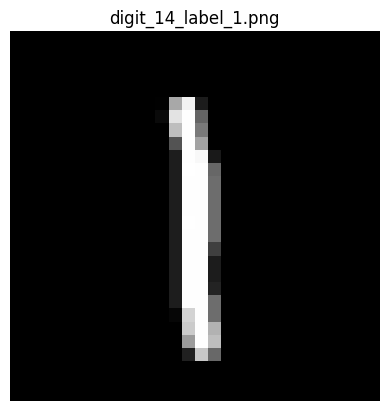

File: digit_14_label_1.png
Predicted Digit: 1
--------------------------------------------------


Text(0.5, 1.0, 'digit_15_label_7.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

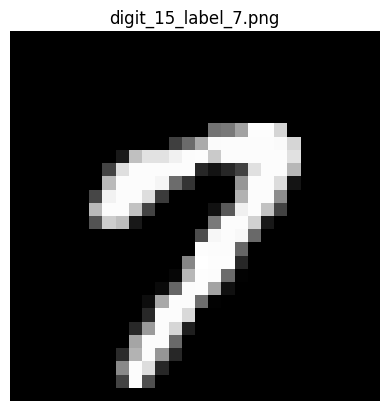

File: digit_15_label_7.png
Predicted Digit: 7
--------------------------------------------------


Text(0.5, 1.0, 'digit_16_label_2.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

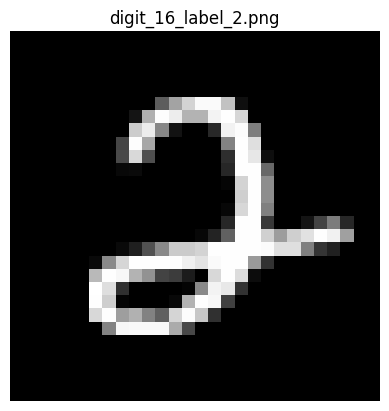

File: digit_16_label_2.png
Predicted Digit: 2
--------------------------------------------------


Text(0.5, 1.0, 'digit_17_label_8.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

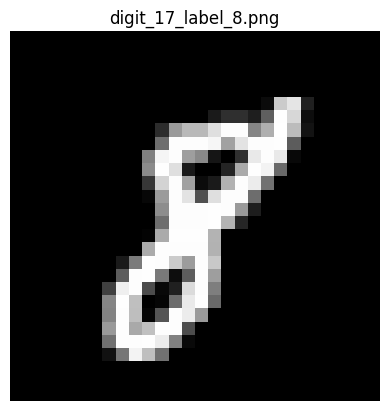

File: digit_17_label_8.png
Predicted Digit: 8
--------------------------------------------------


Text(0.5, 1.0, 'digit_18_label_6.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

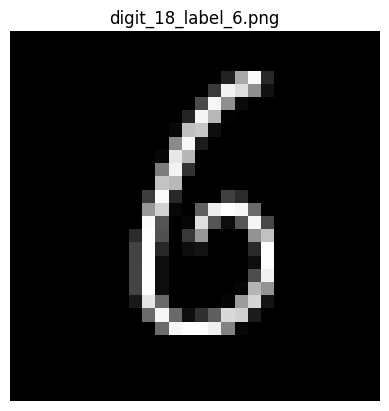

File: digit_18_label_6.png
Predicted Digit: 6
--------------------------------------------------


Text(0.5, 1.0, 'digit_19_label_9.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

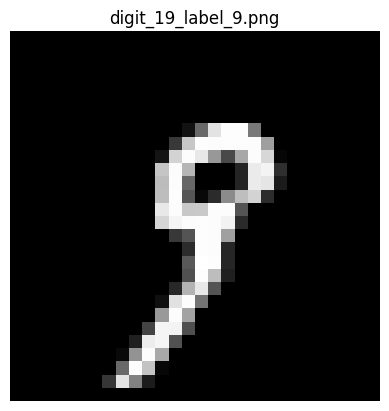

File: digit_19_label_9.png
Predicted Digit: 9
--------------------------------------------------


Text(0.5, 1.0, 'digit_1_label_0.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

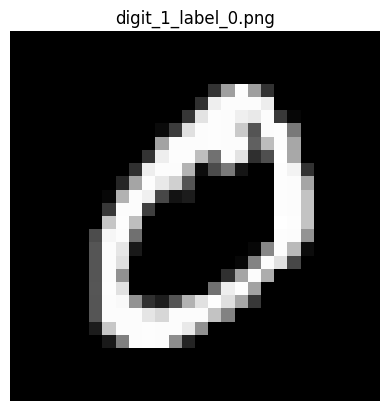

File: digit_1_label_0.png
Predicted Digit: 0
--------------------------------------------------


Text(0.5, 1.0, 'digit_2_label_4.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

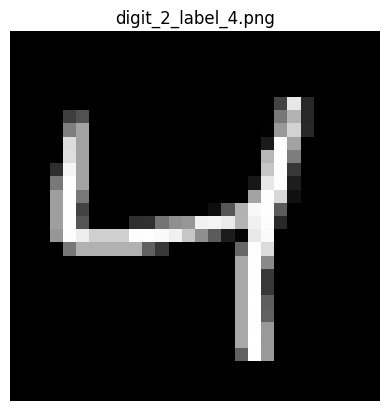

File: digit_2_label_4.png
Predicted Digit: 4
--------------------------------------------------


Text(0.5, 1.0, 'digit_3_label_1.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

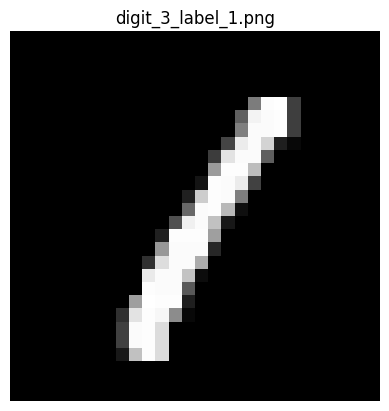

File: digit_3_label_1.png
Predicted Digit: 1
--------------------------------------------------


Text(0.5, 1.0, 'digit_4_label_9.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

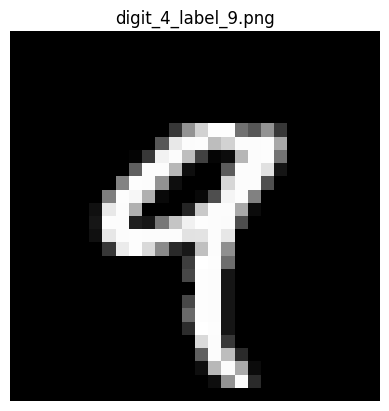

File: digit_4_label_9.png
Predicted Digit: 9
--------------------------------------------------


Text(0.5, 1.0, 'digit_5_label_2.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

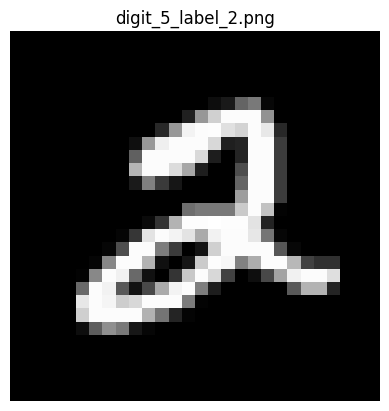

File: digit_5_label_2.png
Predicted Digit: 2
--------------------------------------------------


Text(0.5, 1.0, 'digit_6_label_1.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

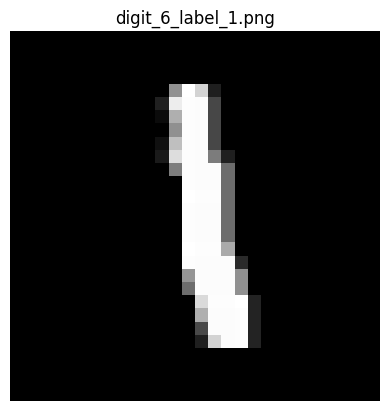

File: digit_6_label_1.png
Predicted Digit: 1
--------------------------------------------------


Text(0.5, 1.0, 'digit_7_label_3.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

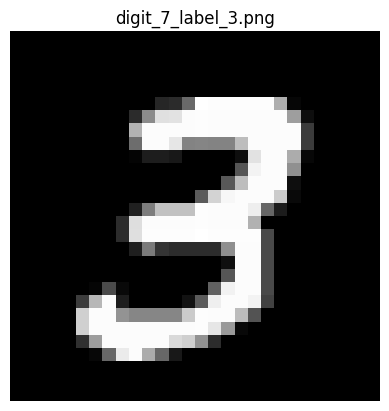

File: digit_7_label_3.png
Predicted Digit: 3
--------------------------------------------------


Text(0.5, 1.0, 'digit_8_label_1.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

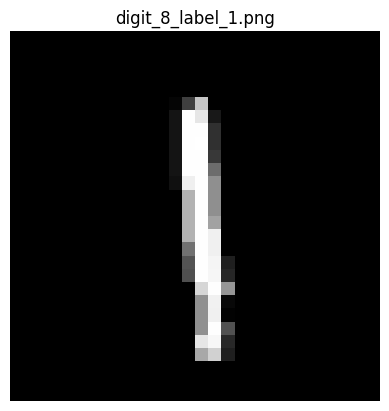

File: digit_8_label_1.png
Predicted Digit: 1
--------------------------------------------------


Text(0.5, 1.0, 'digit_9_label_4.png')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

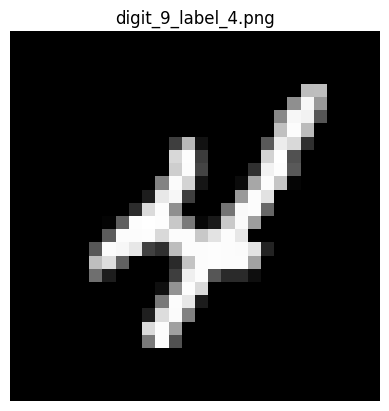

File: digit_9_label_4.png
Predicted Digit: 4
--------------------------------------------------


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Folder containing MNIST images
folder_path = "mnist_test_images"

# Get all PNG files
image_files = [f for f in os.listdir(folder_path) if f.endswith(".png")]

print(f"Total Images Found: {len(image_files)}")

for file_name in image_files:

    # Full image path
    image_path = os.path.join(folder_path, file_name)

    # Open image
    image = Image.open(image_path).convert('L')

    # Resize to 28x28 (optional if already 28x28)
    image = image.resize((28, 28))

    # Display image
    plt.imshow(image, cmap='gray')
    plt.title(file_name)
    plt.axis('off')
    plt.show()

    # Convert image to numpy array
    image_array = np.array(image) / 255.0

    # Reshape for CNN model
    image_array = image_array.reshape(1, 28, 28)

    # Predict
    prediction = model.predict(image_array, verbose=0)

    predicted_digit = np.argmax(prediction)

    print(f"File: {file_name}")
    print(f"Predicted Digit: {predicted_digit}")
    print("-" * 50)